In [ ]:
import os
from collections import Counter

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import wandb
from wandb.integration.keras import WandbMetricsLogger


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np

2026-02-19 13:31:43.470287: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-19 13:31:43.540141: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771504303.579039  285498 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771504303.592860  285498 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771504303.651490  285498 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(5)

# 1. Load the CIFAR-10 dataset. 

In [4]:
# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# # Visualize some examples
class_names = [
  'airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog' ,
  'frog' ,
  'horse',
  'ship',
  'truck'
  ]

labels = y_train.reshape(1,-1)[0]

/home/echerif/miniconda3/envs/ironhack_tf/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


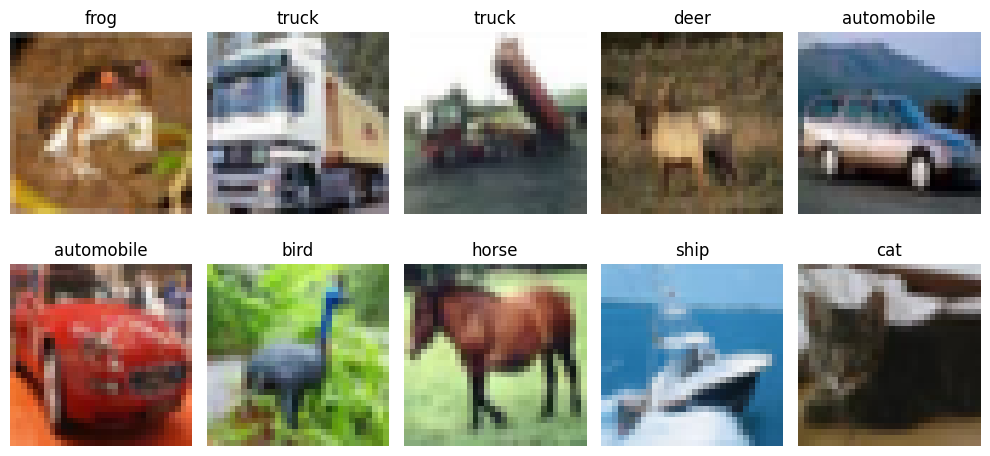

In [5]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

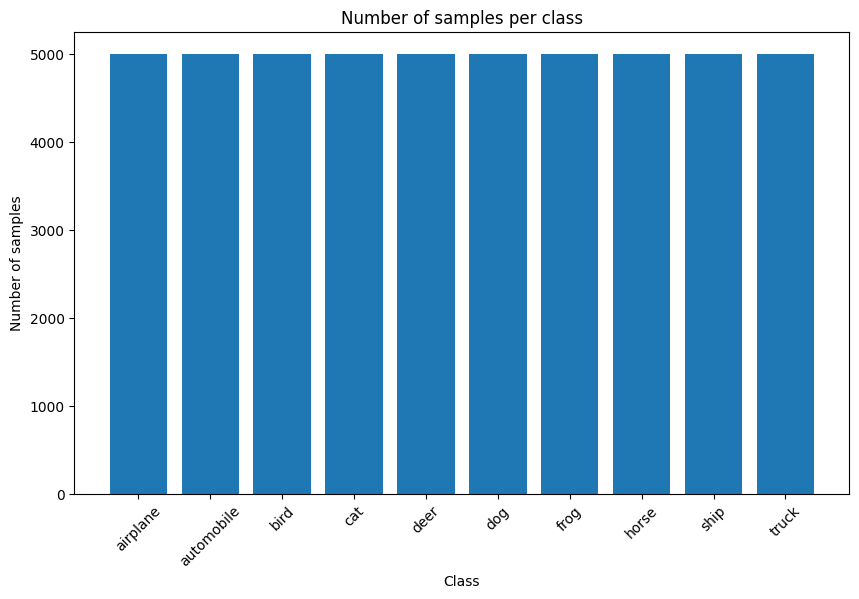

airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


In [6]:
# Count the number of samples per class
class_counts = Counter(labels)

# Sort by class index
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]


# Plotting
plt.figure(figsize=(10, 6))
plt.bar(class_names, counts)
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Number of samples per class')
plt.xticks(rotation=45)
plt.show()

# Optional: print counts for reference
for cls, count in zip(class_names, counts):
    print(f"{cls}: {count}")

# 2. Preprocess the data

In [7]:
X_train.shape

(50000, 32, 32, 3)

In [8]:
# Convert labels to one-hot vectors
num_classes = len(class_names)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Create a preprocessing layer for normalization
normalization_layer = Rescaling(1./255)
X_train = normalization_layer(X_train)
X_test = normalization_layer(X_test)

I0000 00:00:1771504326.792935  285498 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


# 3. Design your CNN models

Start with a simple architecture, then experiment by increasing the number of layers, filters, and other parameters.

In [ ]:
### Model definition
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.summary()

## build in the model
opt = Adam(learning_rate=lr)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

/home/echerif/miniconda3/envs/ironhack_tf/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       921,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 923,914 (3.52 MB)

 Trainable params: 923,914 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Train the model

In [ ]:
### Train the model
history = model.fit(X_train, y_train_cat, epochs=10, validation_split=0.2, batch_size=128)

Epoch 1/10


I0000 00:00:1771490578.051102  245459 service.cc:152] XLA service 0x7f49880049c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771490578.051646  245459 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2026-02-19 09:42:58.144439: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771490578.444824  245459 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-19 09:42:59.921049: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_223', 4 bytes spill stores, 4 bytes spill loads



 15/391 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1417 - loss: 2.3730

I0000 00:00:1771490583.219649  245459 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


388/391 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3565 - loss: 1.8099

2026-02-19 09:43:07.022021: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_388', 148 bytes spill stores, 148 bytes spill loads



391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.4416 - loss: 1.5812 - val_accuracy: 0.5252 - val_loss: 1.3414
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5608 - loss: 1.2543 - val_accuracy: 0.5877 - val_loss: 1.1851
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6077 - loss: 1.1333 - val_accuracy: 0.6059 - val_loss: 1.1435
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6341 - loss: 1.0557 - val_accuracy: 0.6124 - val_loss: 1.1173
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6561 - loss: 0.9935 - val_accuracy: 0.6179 - val_loss: 1.1113
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6685 - loss: 0.9518 - val_accuracy: 0.6415 - val_loss: 1.0252
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6851 - loss: 0.9105 - val_accuracy: 0.6399 - val_loss: 1.0492
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6988 - loss: 0.8700 - val_accuracy: 0.6449 - va

### Evaluation

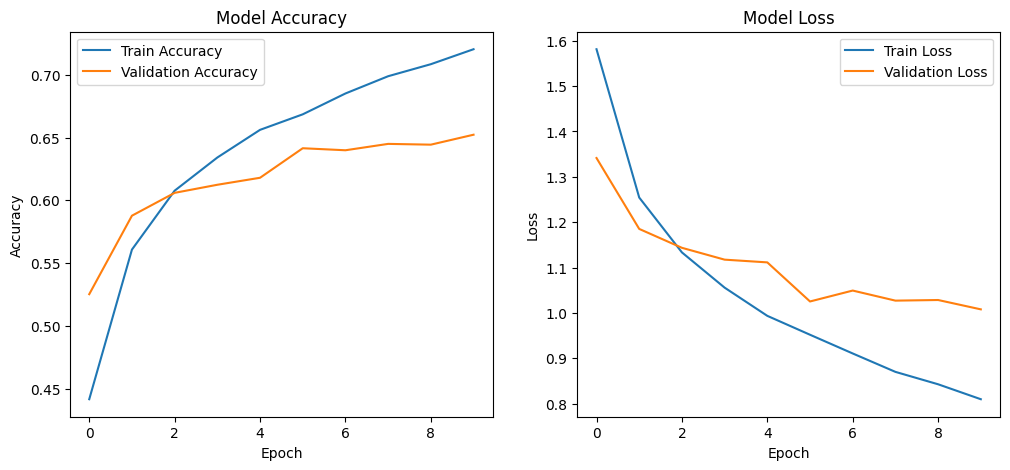

In [21]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 5. Evaluate your models
 Report metrics such as accuracy, precision, recall, and F1-score, and visualize the confusion matrix to analyze class-wise performance.

In [22]:
# Evaluate
loss, accuracy = model.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5614 - loss: 207.9618
Train accuracy: 0.5614
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5098 - loss: 261.2342
Test accuracy: 0.5098


In [23]:
# Predict class probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.5098
Precision: 0.5895
Recall: 0.5098
F1 Score: 0.4697


In [24]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.51      0.75      0.61      1000
  automobile       0.49      0.87      0.63      1000
        bird       0.63      0.20      0.30      1000
         cat       0.31      0.40      0.35      1000
        deer       0.91      0.02      0.04      1000
         dog       0.41      0.52      0.46      1000
        frog       0.85      0.28      0.43      1000
       horse       0.52      0.77      0.62      1000
        ship       0.66      0.73      0.69      1000
       truck       0.62      0.55      0.58      1000

    accuracy                           0.51     10000
   macro avg       0.59      0.51      0.47     10000
weighted avg       0.59      0.51      0.47     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


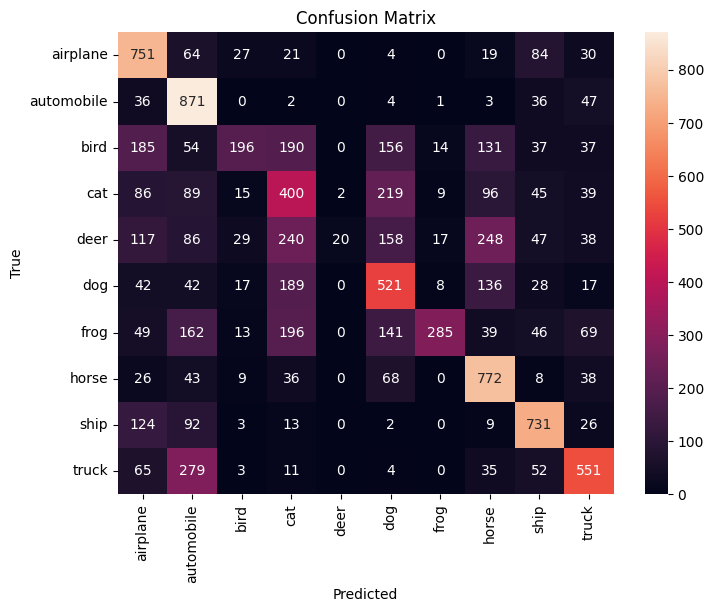

In [ ]:
# Predict & confusion matrix
y_pred = model.predict(X_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# 6. Improve the baseline

### Regularization:

In [ ]:
# Define deeper CNN model
model_reg = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    # ## Regularization
    BatchNormalization(),
    MaxPooling2D(2,2),
    ## Regularization
    Dropout(0.5),

    Flatten(),

    Dense(128, activation='relu'), ## start lower > increase interatively : add neuron the add layers >> increase complexity
    ## Regularization
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_reg.summary()

opt = Adam(learning_rate=lr)
model_reg.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     1,843,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,846,922 (7.05 MB)

 Trainable params: 1,846,922 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train on original data
history_reg = model_reg.fit(X_train, y_train_cat, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8135 - loss: 0.5393 - val_accuracy: 0.6470 - val_loss: 1.1150
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8227 - loss: 0.5199 - val_accuracy: 0.6536 - val_loss: 1.1310
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8284 - loss: 0.4970 - val_accuracy: 0.6460 - val_loss: 1.1406
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8335 - loss: 0.4836 - val_accuracy: 0.6373 - val_loss: 1.2040
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8448 - loss: 0.4556 - val_accuracy: 0.6387 - val_loss: 1.2154
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8509 - loss: 0.4389 - val_accuracy: 0.6450 - val_loss: 1.2142
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8574 - loss: 0.4203 - val_accuracy: 0.6379 - val_loss: 1.2760
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8641 - loss: 0.4024 - val_accuracy: 0.

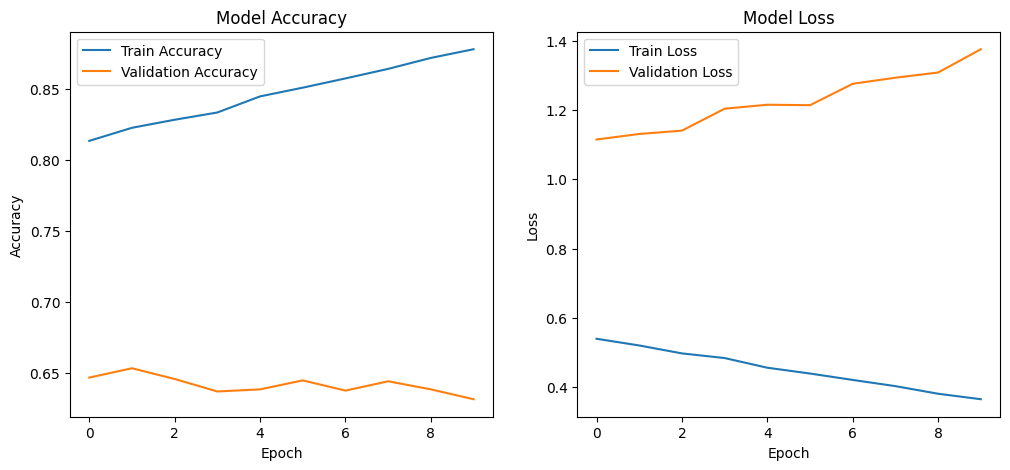

In [36]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_reg.history['accuracy'], label='Train Accuracy')
plt.plot(history_reg.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_reg.history['loss'], label='Train Loss')
plt.plot(history_reg.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [32]:
# Evaluate
loss, accuracy = model_reg.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model_reg.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.1211 - loss: 64.7269
Train accuracy: 0.1211
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1249 - loss: 65.0163
Test accuracy: 0.1249


### Deeper model

In [ ]:
model_deeper = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model_deeper.summary()

opt = Adam(learning_rate=lr)
model_deeper.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
### Train
history_deeper = model_deeper.fit(X_train, y_train_cat, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.1995 - loss: 2.4121 - val_accuracy: 0.1709 - val_loss: 4.5704
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3490 - loss: 1.7533 - val_accuracy: 0.3641 - val_loss: 2.1997
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4035 - loss: 1.6255 - val_accuracy: 0.4181 - val_loss: 1.9600
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4426 - loss: 1.5384 - val_accuracy: 0.5060 - val_loss: 1.4838
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4653 - loss: 1.4787 - val_accuracy: 0.5139 - val_loss: 1.4253
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4887 - loss: 1.4224 - val_accuracy: 0.4873 - val_loss: 1.6522
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4990 - loss: 1.3818 - val_accuracy: 0.5432 - val_loss: 1.3550
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5221 - loss: 1.3365 - val_accuracy:

- Solved overfitting for 10 epochs and imporved the perfoemance

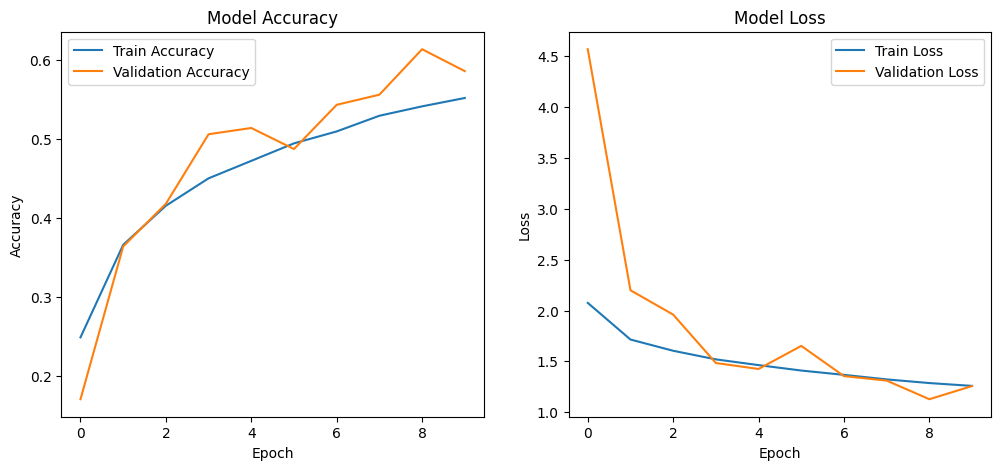

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_deeper.history['accuracy'], label='Train Accuracy')
plt.plot(history_deeper.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_deeper.history['loss'], label='Train Loss')
plt.plot(history_deeper.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Evaluate
loss, accuracy = model_deeper.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model_deeper.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6055 - loss: 1.1721
Train accuracy: 0.6002
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5941 - loss: 1.2432
Test accuracy: 0.5908


In [ ]:
# Predict class probabilities
y_pred_probs = model_deeper.predict(X_test)

# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Accuracy: 0.5908
Precision: 0.6216
Recall: 0.5908
F1 Score: 0.5834


### Data augmentation

In [ ]:
model_deeper = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model_deeper.summary()

opt = Adam(learning_rate=lr)
model_deeper.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)


In [ ]:
# Use in model training
history_aug = model_deeper.fit(datagen.flow(X_train, y_train_cat, batch_size=128, shuffle=True),
          epochs=10,
          validation_data=(X_test, y_test_cat))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 83ms/step - accuracy: 0.2762 - loss: 1.9568 - val_accuracy: 0.4832 - val_loss: 1.4352
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.4386 - loss: 1.5529 - val_accuracy: 0.5385 - val_loss: 1.2825
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.4820 - loss: 1.4409 - val_accuracy: 0.5832 - val_loss: 1.1813
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.5110 - loss: 1.3677 - val_accuracy: 0.6065 - val_loss: 1.1033
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.5297 - loss: 1.3126 - val_accuracy: 0.6160 - val_loss: 1.0864
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.5531 - loss: 1.2601 - val_accuracy: 0.6211 - val_loss: 1.0721
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.5615 - loss: 1.2428 - val_accuracy: 0.6450 - val_loss: 1.0044
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.5699 - loss: 1.2179 - 

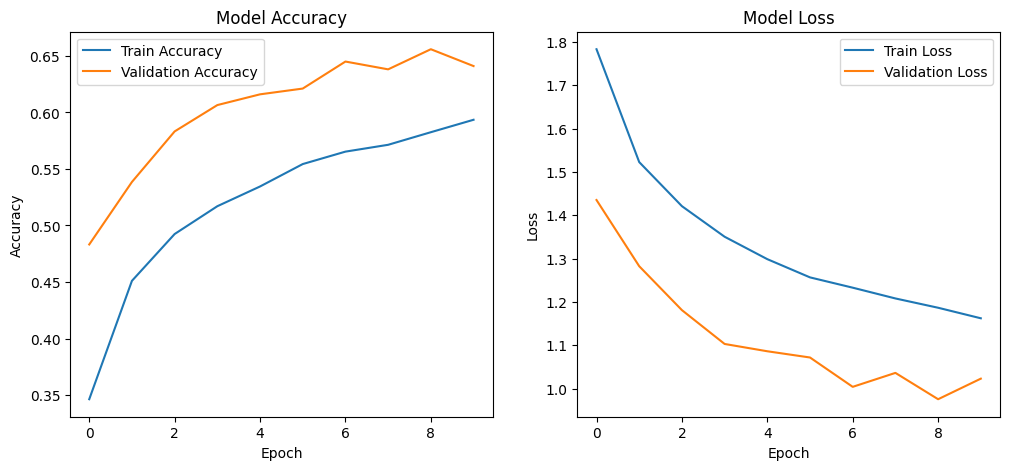

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_aug.history['accuracy'], label='Train Accuracy')
plt.plot(history_aug.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_aug.history['loss'], label='Train Loss')
plt.plot(history_aug.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Evaluate
loss, accuracy = model_deeper.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model_deeper.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6493 - loss: 1.0013
Train accuracy: 0.6468
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6440 - loss: 1.0145
Test accuracy: 0.6410


### Early stopping

In [ ]:
model_deeper = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model_deeper.summary()

opt = Adam(learning_rate=lr)
model_deeper.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [ ]:
# Setup EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',   # metric to monitor
    patience=5,           # stop if no improvement after n epochs
    restore_best_weights=True
)

In [ ]:
# Train the model with early stopping
history_early_st = model_deeper.fit(
          datagen.flow(X_train, y_train_cat, batch_size=128, shuffle=True),
          epochs=100,
          validation_data=(X_test, y_test_cat),
          callbacks=[early_stopping]
                               )

Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 54s 125ms/step - accuracy: 0.2005 - loss: 2.3777 - val_accuracy: 0.2871 - val_loss: 2.8498
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.3301 - loss: 1.8086 - val_accuracy: 0.4131 - val_loss: 1.5934
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.3795 - loss: 1.6861 - val_accuracy: 0.4316 - val_loss: 1.6683
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.4103 - loss: 1.6258 - val_accuracy: 0.4921 - val_loss: 1.4168
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.4366 - loss: 1.5583 - val_accuracy: 0.5448 - val_loss: 1.3027
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 101ms/step - accuracy: 0.4513 - loss: 1.5202 - val_accuracy: 0.5082 - val_loss: 1.4900
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.4642 - loss: 1.4855 - val_accuracy: 0.5444 - val_loss: 1.3369
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.4786 - loss:

In [ ]:
# Evaluate the model
## higher patience
loss, accuracy = model_deeper.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model_deeper.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6643 - loss: 0.9577
Train accuracy: 0.6630
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6589 - loss: 0.9770
Test accuracy: 0.6558


In [ ]:
# Evaluate the model
## with higher lr
loss, accuracy = model_deeper.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model_deeper.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4548 - loss: 1.5052
Train accuracy: 0.4540
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4518 - loss: 1.4847
Test accuracy: 0.4546


In [ ]:
# Evaluate the model
## first run
loss, accuracy = model_deeper.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model_deeper.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5640 - loss: 1.2287
Train accuracy: 0.5638
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5577 - loss: 1.2465
Test accuracy: 0.5603


# 7. CNN improved model With Wandb

In [ ]:
# !wandb login

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/echerif/.netrc
wandb: Currently logged in as: eya-cherif14 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [10]:
lr = 1e-3
epochs = 100
batch_size = 128

In [11]:
model_deeper = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model_deeper.summary()


opt = Adam(learning_rate=lr)
model_deeper.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

/home/echerif/miniconda3/envs/ironhack_tf/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

In [12]:
# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [13]:
# Setup EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',   # metric to monitor
    patience=10,           # stop if no improvement after n epochs
    restore_best_weights=True
)

In [14]:
# Initialize wandb run
name_model = 'CNN_model_2layers'

### Group account
wandb.init(
    entity="Ironhack_cnn_project",                  # ← your team name
    project="cifar10_dataset_FantasticFour",  # ← project gets created automatically!
    name= name_model,
    config={                    # hyperparameters to track
        "epochs": epochs,
        "batch_size": batch_size,
        "optimizer": "adam",
        "learning_rate": lr,
        "augmentation": True
    }
)

In [15]:
# Train with WandbCallback
model_deeper.fit(
    datagen.flow(X_train, y_train_cat, batch_size=batch_size, shuffle=True),
    epochs=epochs,
    validation_data=(X_test, y_test_cat),
    callbacks=[
        early_stopping,
        WandbMetricsLogger(log_freq="epoch")  # logs everything!
    ]
)

Epoch 1/100


I0000 00:00:1771504398.040109  285674 service.cc:152] XLA service 0x7f15dc022730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771504398.040342  285674 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2026-02-19 13:33:18.164554: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771504398.633728  285674 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/391 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.0916 - loss: 6.0829   

I0000 00:00:1771504405.649091  285674 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 62/391 ━━━━━━━━━━━━━━━━━━━━ 22s 67ms/step - accuracy: 0.1343 - loss: 3.2332

2026-02-19 13:33:31.544365: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2215', 52 bytes spill stores, 52 bytes spill loads



391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1952 - loss: 2.3804

2026-02-19 13:33:57.245413: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_141', 4 bytes spill stores, 4 bytes spill loads



391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 90ms/step - accuracy: 0.2424 - loss: 2.0740 - val_accuracy: 0.2189 - val_loss: 3.1749
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.3379 - loss: 1.7834 - val_accuracy: 0.4611 - val_loss: 1.4944
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.3809 - loss: 1.6773 - val_accuracy: 0.4646 - val_loss: 1.4795
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.4161 - loss: 1.6105 - val_accuracy: 0.4157 - val_loss: 1.7793
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.4337 - loss: 1.5597 - val_accuracy: 0.4091 - val_loss: 2.0238
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.4522 - loss: 1.5114 - val_accuracy: 0.5248 - val_loss: 1.3789
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.4685 - loss: 1.4723 - val_accuracy: 0.5484 - val_loss: 1.2907
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.4864 - loss: 1.4402 - val_

In [16]:
### Evaluation ##
train_loss, train_acc = model_deeper.evaluate(datagen.flow(X_train, y_train_cat, batch_size=batch_size), verbose=0)
test_loss, test_acc = model_deeper.evaluate(X_test, y_test_cat, verbose=0)

# Log summary table to wandb
wandb.log({
    "summary_table": wandb.Table(
        columns=["Split", "Loss", "Accuracy"],
        data=[
            ["Train", round(train_loss, 4), round(train_acc, 4)],
            ["Test/Val", round(test_loss, 4), round(test_acc, 4)]
        ]
    )
})

2026-02-19 13:48:21.323177: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_143', 4 bytes spill stores, 4 bytes spill loads



In [ ]:
# Save model locally first
model_deeper.save(f"{name_model}.keras")

# Log it to wandb as an artifact
artifact = wandb.Artifact(
    name= name_model,        # artifact name
    type="model",                # type
    # description="My best model"
)
artifact.add_file(f"{name_model}.keras")   # attach the file
wandb.log_artifact(artifact)          # upload to wandb

# Mark run as finished
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch/accuracy,▁▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████████
epoch/epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▅▅▄▄▆▆▆▆▅▅▆▇▇▄█▇▇▆▆████▇▇██▇▆▇▇▇
epoch/val_loss,█▃▃▄▄▂▂▃▂▄▃▃▂▂▄▁▁▂▃▃▁▁▁▁▂▂▁▁▂▃▁▂▂
epoch/accuracy,0.5973
epoch/epoch,32
epoch/learning_rate,0.001
epoch/loss,1.15003
epoch/val_accuracy,0.6187


### Evaluation of the model

In [ ]:
### Load the model if necessary 
# name = ''
# model_deeper = tf.keras.models.load_model(f"{name}.keras")

# # Then load just the weights
# model_deeper.load_weights(f"{name}.keras")
# model_deeper

In [18]:
# Predict class probabilities
y_pred_probs = model_deeper.predict(X_test)
# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
# y_pred = model_deeper.predict(X_test).argmax(axis=1)

y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Accuracy: 0.6745
Precision: 0.6840
Recall: 0.6745
F1 Score: 0.6630


In [19]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.81      0.61      0.70      1000
  automobile       0.83      0.77      0.80      1000
        bird       0.71      0.38      0.49      1000
         cat       0.58      0.36      0.45      1000
        deer       0.58      0.68      0.62      1000
         dog       0.64      0.53      0.58      1000
        frog       0.56      0.91      0.70      1000
       horse       0.68      0.77      0.72      1000
        ship       0.76      0.87      0.81      1000
       truck       0.68      0.87      0.76      1000

    accuracy                           0.67     10000
   macro avg       0.68      0.67      0.66     10000
weighted avg       0.68      0.67      0.66     10000



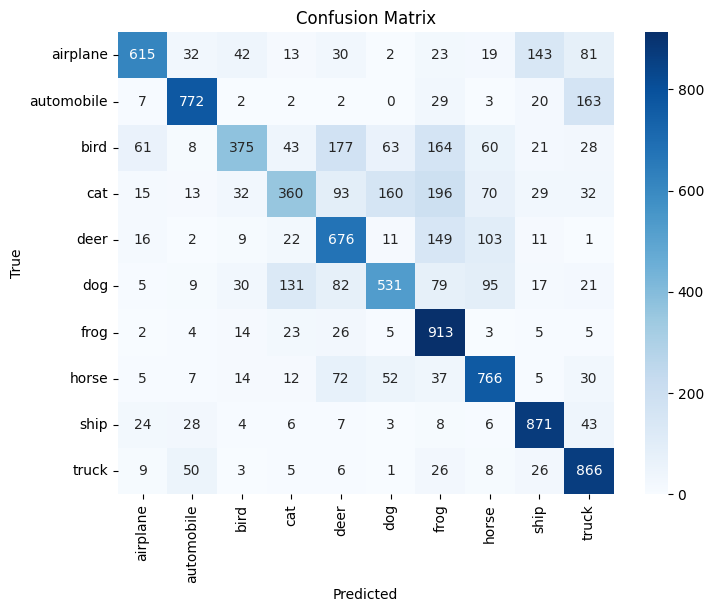

In [21]:
# Predict & confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cmap="Blues")        # ✅ just add this!
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()